In [1]:
import sys
from functools import partial
sys.path.append('../')
from spd.OperatorSequence import *
from spd.SparsePauliDynamics import *
from spd.LightPauliDynamics import *
from pauli import *
fig_dir, data_dir = './figs', './data'
from quantum_simulation_recipe.spin import Nearest_Neighbour_1d
from qiskit.quantum_info import SparsePauliOp
import matplotlib.pyplot as plt

scale = 1
n = 10
t = 3 / scale
r = 200
dt = t/r
w = 4
hx, hy, Jx = 1*scale, 0.9*scale, 0.8*scale
# n = 21
qimf = Nearest_Neighbour_1d(n, hx=hx, hy=hy, Jx=Jx, pbc=False)
xx_even = SparsePauliOp.from_sparse_list([*qimf.xx_tuples[::2]], num_qubits=n).simplify()
xx_odd = SparsePauliOp.from_sparse_list([*qimf.xx_tuples[1::2]], num_qubits=n).simplify()
x_terms = SparsePauliOp.from_sparse_list([*qimf.x_tuples], num_qubits=n).simplify()
H_list = [xx_even, x_terms, qimf.y_terms, xx_odd]
ops = dt*sum(H_list)
obs = SparsePauliOp('I'*(n-1)+'Z', 1)
print('ops:', ops)
print('obs:', obs)

def exp_val_func(observable):
    return observable.overlap(PauliRepresentation.from_sparse_pauli_op(obs)) 
    # return [observable.overlap(PauliRepresentation.from_sparse_pauli_op(h)) for h in [obs]]
exp_val_func = partial(exp_val_0101_state_pauli_rep, n_qubits=n)
# exp_val_func = exp_val_all_zeros_pauli_rep

ops: SparsePauliOp(['IIIIIIIIXX', 'IIIIIIXXII', 'IIIIXXIIII', 'IIXXIIIIII', 'XXIIIIIIII', 'IIIIIIIIIX', 'IIIIIIIIXI', 'IIIIIIIXII', 'IIIIIIXIII', 'IIIIIXIIII', 'IIIIXIIIII', 'IIIXIIIIII', 'IIXIIIIIII', 'IXIIIIIIII', 'XIIIIIIIII', 'IIIIIIIIIY', 'IIIIIIIIYI', 'IIIIIIIYII', 'IIIIIIYIII', 'IIIIIYIIII', 'IIIIYIIIII', 'IIIYIIIIII', 'IIYIIIIIII', 'IYIIIIIIII', 'YIIIIIIIII', 'IIIIIIIXXI', 'IIIIIXXIII', 'IIIXXIIIII', 'IXXIIIIIII'],
              coeffs=[0.012 +0.j, 0.012 +0.j, 0.012 +0.j, 0.012 +0.j, 0.012 +0.j, 0.015 +0.j,
 0.015 +0.j, 0.015 +0.j, 0.015 +0.j, 0.015 +0.j, 0.015 +0.j, 0.015 +0.j,
 0.015 +0.j, 0.015 +0.j, 0.015 +0.j, 0.0135+0.j, 0.0135+0.j, 0.0135+0.j,
 0.0135+0.j, 0.0135+0.j, 0.0135+0.j, 0.0135+0.j, 0.0135+0.j, 0.0135+0.j,
 0.0135+0.j, 0.012 +0.j, 0.012 +0.j, 0.012 +0.j, 0.012 +0.j])
obs: SparsePauliOp(['IIIIIIIIIZ'],
              coeffs=[1.+0.j])


In [19]:
sim = LowWeightPauliPropagation.from_pauli_list(obs, ops, threshold=w, nprocs=4)
res = sim.run_dynamics(r, process=exp_val_func, process_every = 1, verbose=False)
res = np.array(res)
res = res / res[0].sum()
print(sim.observable.size(), np.linalg.norm(sim.observable.coeffs)/np.linalg.norm(obs.coeffs))

100%|██████████| 200/200 [00:55<00:00,  3.61it/s]

20604 0.9954302741585305


/opt/homebrew/Caskroom/miniforge/base/lib/python3.10/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/homebrew/Caskroom/miniforge/base/lib/python3.10/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


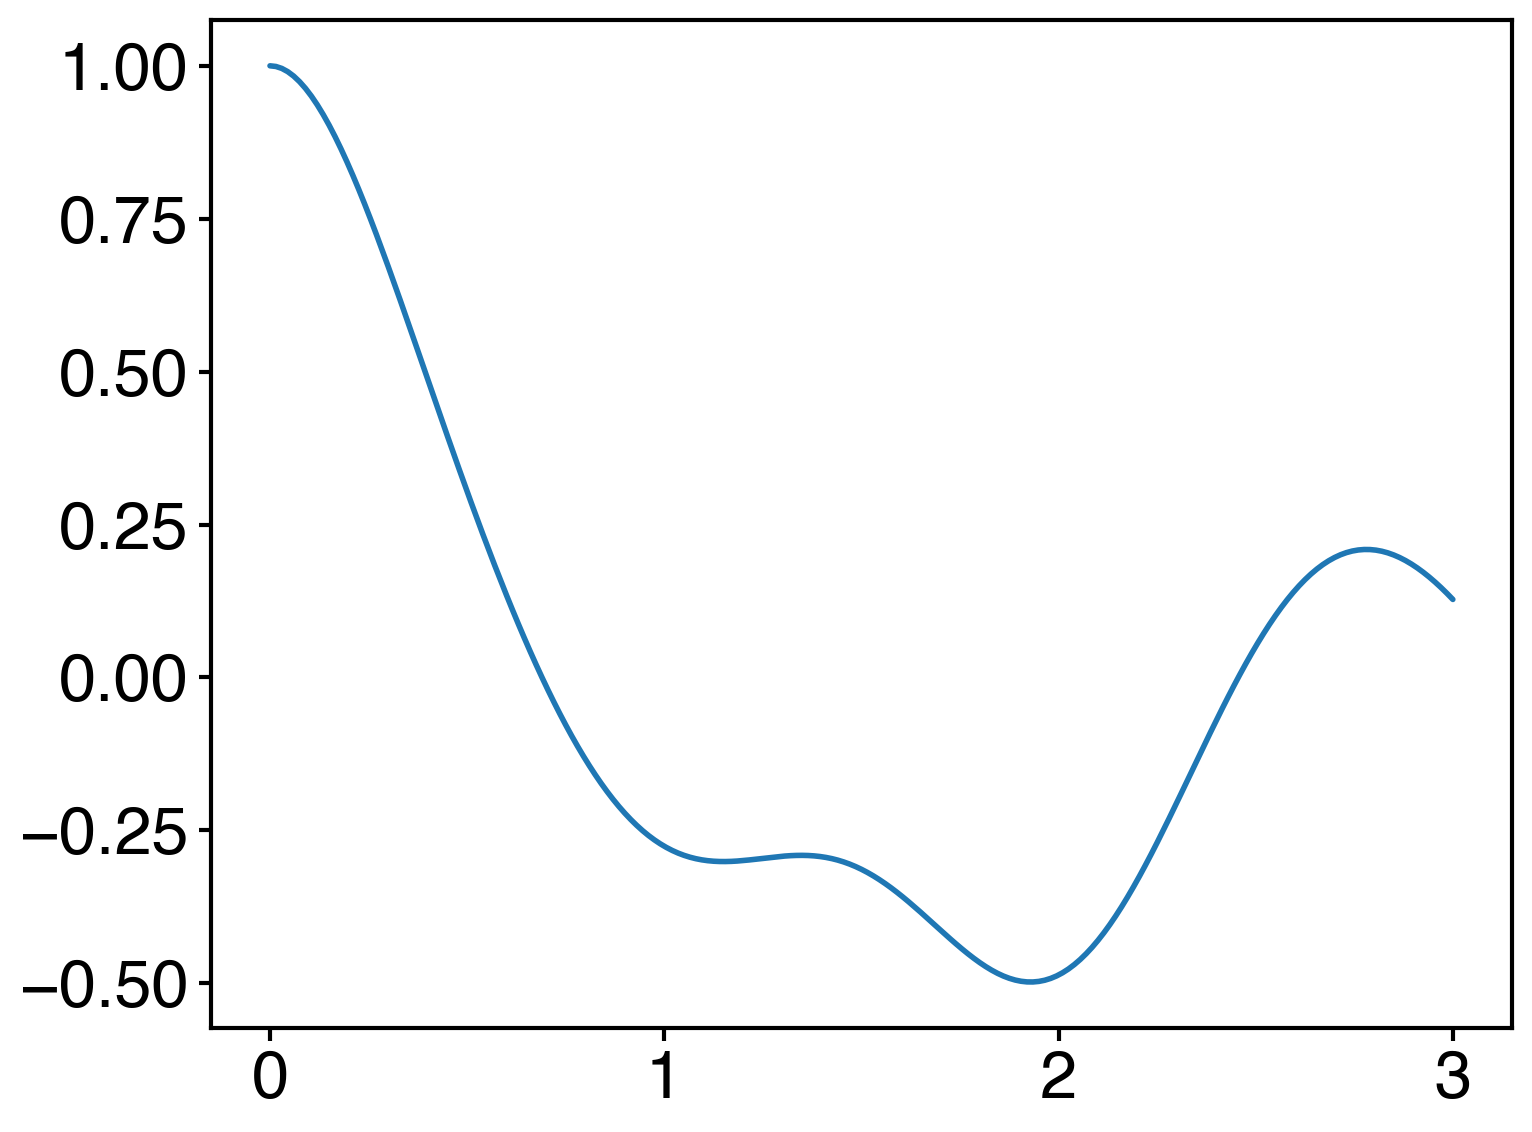

In [21]:
fig, ax = plt.subplots()
ax.plot(np.arange(res.shape[0])*dt, res[:], label='PPHE')
# ax.plot(np.arange(r.shape[0])*dt, r[:,0], label='PPHE')
fig.savefig(f'{fig_dir}/lpd_n{n}_w{w}_t{t}_r{r}.pdf')

In [4]:
print(sim.observable.weights)
sim.observable.to_sparse_pauli_op(nsites)

[1 1 2 2 2 3 2 2 2 2]


SparsePauliOp(['IIIIXIII', 'IIIIZIII', 'IIIIZZII', 'IIIIZYII', 'IIIIYZII', 'IIIZXZII', 'IIIZZIII', 'IIIZYIII', 'IIIYZIII', 'IIIYYIII'],
              coeffs=[ 1.3935039 -4.10911073e-19j,  0.90591233-3.46672283e-19j,
  0.501549  -9.38399729e-20j,  0.0560543 -1.03052399e-17j,
 -0.05560283-6.83697715e-18j, -0.00334157-2.73625959e-19j,
  0.50154393-9.24911901e-20j, -0.05552042-6.85102816e-18j,
  0.0561087 -1.03399377e-17j, -0.00155498-1.91878935e-19j])

In [13]:
gx = 1.4
gz = 0.9045
nsites = 8
# nsites = 21
hx = SparsePauliOp.from_sparse_list([('X', [i], gx) for i in range(nsites)], num_qubits=nsites)
hz = SparsePauliOp.from_sparse_list([('Z', [i], gz) for i in range(nsites)], num_qubits=nsites)
hzz = SparsePauliOp.from_sparse_list([('ZZ', [i, i+1], 1.0) for i in range(nsites-1)], num_qubits=nsites)
print(hx._pauli_list)
print(hx._coeffs)
hi = [hx[0] + hz[0] + hzz[0]/2] + [hx[i] + hz[i] + hzz[i-1] / 2 + hzz[i] / 2 for i in range(1, nsites-1)] + [hx[nsites-1] + hz[nsites-1] + hzz[nsites-2]/2]
# print(hi)

def exp_val_func(observable):
    return [observable.overlap(PauliRepresentation.from_sparse_pauli_op(h)) for h in hi]

['IIIIIIIX', 'IIIIIIXI', 'IIIIIXII', 'IIIIXIII', 'IIIXIIII', 'IIXIIIII',
 'IXIIIIII', 'XIIIIIII']
[1.4+0.j 1.4+0.j 1.4+0.j 1.4+0.j 1.4+0.j 1.4+0.j 1.4+0.j 1.4+0.j]


In [14]:
dt = 0.01
nsteps = 4
threshold = 0.001
# nsteps = 200
# threshold = 0.00001
ops = dt*(hz + hzz + hx)
obs = hi[(nsites-1)//2]
print('ops:', ops)
print('obs:', obs)

sim = Simulation.from_pauli_list(obs, ops, threshold=threshold, nprocs=4)
r = sim.run_dynamics(nsteps, process=exp_val_func, process_every = 10)
r = np.array(r)
r = r / r[0].sum()
print(sim.observable.size(), np.linalg.norm(sim.observable.coeffs)/np.linalg.norm(obs.coeffs))


ops: SparsePauliOp(['IIIIIIIZ', 'IIIIIIZI', 'IIIIIZII', 'IIIIZIII', 'IIIZIIII', 'IIZIIIII', 'IZIIIIII', 'ZIIIIIII', 'IIIIIIZZ', 'IIIIIZZI', 'IIIIZZII', 'IIIZZIII', 'IIZZIIII', 'IZZIIIII', 'ZZIIIIII', 'IIIIIIIX', 'IIIIIIXI', 'IIIIIXII', 'IIIIXIII', 'IIIXIIII', 'IIXIIIII', 'IXIIIIII', 'XIIIIIII'],
              coeffs=[0.009045+0.j, 0.009045+0.j, 0.009045+0.j, 0.009045+0.j, 0.009045+0.j,
 0.009045+0.j, 0.009045+0.j, 0.009045+0.j, 0.01    +0.j, 0.01    +0.j,
 0.01    +0.j, 0.01    +0.j, 0.01    +0.j, 0.01    +0.j, 0.01    +0.j,
 0.014   +0.j, 0.014   +0.j, 0.014   +0.j, 0.014   +0.j, 0.014   +0.j,
 0.014   +0.j, 0.014   +0.j, 0.014   +0.j])
obs: SparsePauliOp(['IIIIXIII', 'IIIIZIII', 'IIIIZZII', 'IIIZZIII'],
              coeffs=[1.4   +0.j, 0.9045+0.j, 0.5   +0.j, 0.5   +0.j])


100%|██████████| 4/4 [00:00<00:00, 129.89it/s]

10 0.9999978313840797


In [6]:
tp = PauliRepresentation.from_pauli_list(PauliList('XYZII'))
tsop = tp.to_sparse_pauli_op(5)
print(tsop, tp.nq)
# print(PauliList('XYZII')._z)
print('weight of single Pauli: ', tp.weights)
# print(tp)
# Create some Pauli operators
paulis = PauliList(['XYZII', 'IIIII', 'ZZZZZ', 'XXIII'])
# Convert to PauliRepresentation
pauli_rep = PauliRepresentation.from_pauli_list(paulis, [1,2,3,4])
print('number of Paulis:', pauli_rep.n_pauli)
print('bit rep: ', pauli_rep.bits)
print('weights: ', pauli_rep.weights)
print('phases: ', pauli_rep.phase)
print('coeffs: ', pauli_rep.coeffs)
print('2 norm: ', pauli_rep.p2norm())
pauli_rep_w = decompose_by_weight_pauli_rep(pauli_rep)
# print(pauli_rep_w[0])
for key in pauli_rep_w:
    item = pauli_rep_w[key]
    print(item.p2norm()**2, item.weights, item.size())


# Get weights efficiently
weights = pauli_rep.weight()
print(f"Weights: {weights}")  # Output: Weights: [3 0 5 2]
print('anticommutes: ', pauli_rep.anticommutes(tp))
print('indices (anti):', np.where(pauli_rep.anticommutes(tp))[0])

SparsePauliOp(['XYZII'],
              coeffs=[1.+0.j]) 1
weight of single Pauli:  [3]
number of Paulis: 4
bit rep:  [[12 24]
 [ 0  0]
 [31  0]
 [ 0 24]]
weights:  [3 0 5 2]
phases:  [1 0 0 0]
coeffs:  [1, 2, 3, 4]
2 norm:  3.8729833462074166
1.9999999999999996 [0] 1
7.999999999999998 [2] 1
0.4999999999999999 [3] 1
4.499999999999999 [5] 1
Weights: [3 0 5 2]
anticommutes:  [False False False  True]
indices (anti): [3]


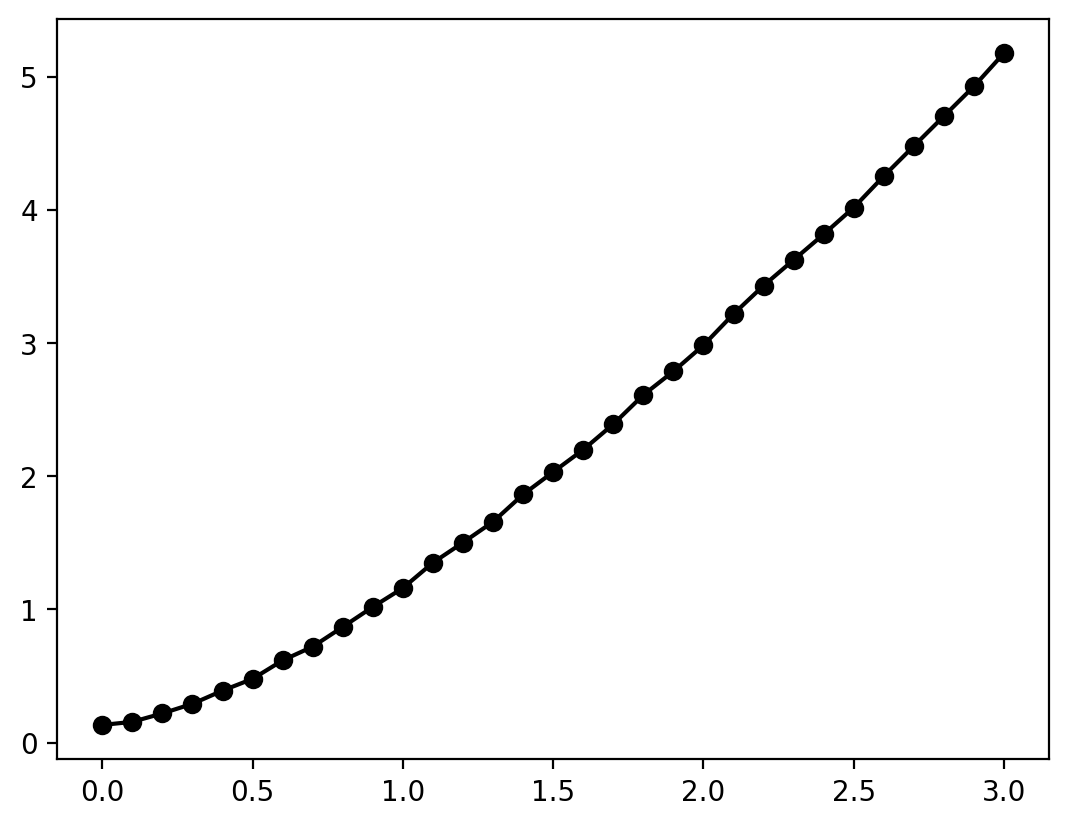

In [ ]:
def msd(a):
    j = np.arange(1,len(a)+1)
    return np.sum(a*j**2) - np.sum(a*j)**2
d2 = [msd(ri) for ri in r]

fig, ax = plt.subplots(1, 1)
ax.plot(np.arange(len(d2))/10, abs(np.array(d2)), '-ok')
# ax.set_ylim(0, 7)
plt.show()